In [29]:
from framework import (
    EpsilonGreedy,
    FPA_AuctionEnvironment,
    SPA_AuctionEnvironment,
    AuctionSimulation
)

In [31]:
#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0)
bidder2 = EpsilonGreedy(name="Agent2", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0)

#run simulation for FPA or SPA
simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
history = simulation.run()

Convergence detected after 93526 rounds.
Bidder Agent1 had converged to  0.1
Bidder Agent2 had converged to  0.1


In [32]:
def extract_q_trajectory(history, bidder_name, bid_index):
    return [q_vals[bidder_name][bid_index] for *_, q_vals in history]

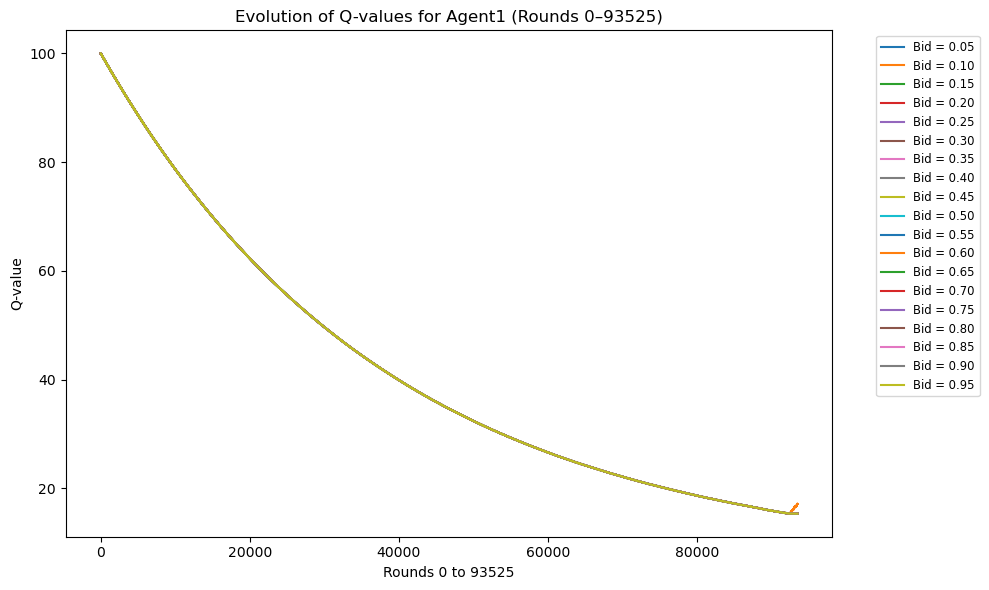

In [35]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

def plot_q_evolution_range(history, bidder_name, start_round, end_round):
    """
    Plot Q-value trajectories for all bids of `bidder_name` between
    start_round and end_round (inclusive).
    
    Parameters
    ----------
    history : list
        Auction history, where each element ends with q_snapshot: {bidder_name: q_values}.
    bidder_name : str
        Name of the bidder to plot.
    start_round : int
        Index of the starting round (0-based).
    end_round : int
        Index of the ending round (0-based, inclusive).
    """
    n = len(history)
    if n == 0:
        raise ValueError("History is empty.")
    if start_round < 0 or end_round >= n:
        raise ValueError(f"start_round and end_round must be within [0, {n-1}].")
    if end_round < start_round:
        raise ValueError("end_round must be greater than or equal to start_round.")

    # Slice history for the given range
    hist_slice = history[start_round:end_round+1]

    # Bid grid (same as in your environment)
    bid_options = np.array([i*0.05 for i in range(1, 20)])
    num_bids = len(bid_options)

    # Plot trajectories
    plt.figure(figsize=(10, 6))
    for bid_idx in range(num_bids):
        q_traj = extract_q_trajectory(hist_slice, bidder_name, bid_idx)
        plt.plot(range(start_round, end_round+1), q_traj, label=f"Bid = {bid_options[bid_idx]:.2f}")

    plt.xlabel(f"Rounds {start_round} to {end_round}")
    plt.ylabel("Q-value")
    plt.title(f"Evolution of Q-values for {bidder_name} (Rounds {start_round}–{end_round})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
    plt.tight_layout()
    plt.show()

plot_q_evolution_range(history, "Agent1", 0, 93525)

In [36]:
#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0)
bidder2 = EpsilonGreedy(name="Agent2", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, stochastic=0)

#run simulation for FPA or SPA
simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=10000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
history_2 = simulation.run()

Agents have not converged after 1,000,000 rounds
